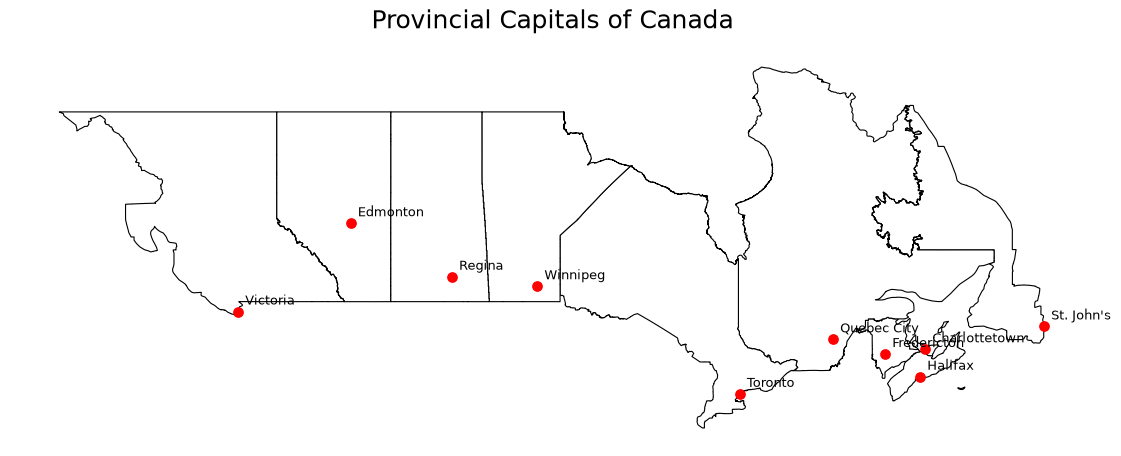

In [19]:
# ============================================================
# 30DayMapChallenge — Map of Canadian Provincial Capitals
# ============================================================
#
# This script:
#   1. Downloads Canadian province/territory boundaries
#      from Statistics Canada
#   2. Keeps only the 10 Canadian provinces
#   3. Creates a table of the 10 provincial capitals
#   4. Converts capital coordinates into geographic points
#   5. Plots the provinces and capital cities
#   6. Labels each provincial capital
#
# CRS used:
#   EPSG:4326 — WGS 84 longitude/latitude
# ============================================================


# ------------------------------------------------------------
# 1. IMPORT LIBRARIES
# ------------------------------------------------------------

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from shapely.geometry import Point


# ------------------------------------------------------------
# 2. DOWNLOAD PROVINCE AND TERRITORY BOUNDARIES
# ------------------------------------------------------------
#
# Statistics Canada provides a GeoJSON-compatible REST endpoint
# containing Canada's provinces and territories.
#
# We request:
#   - PRNAME       = province/territory name
#   - Geometry     = polygon boundaries
#
# The original dataset contains 13 provinces/territories.
# ------------------------------------------------------------

url = (
    "https://geo.statcan.gc.ca/geo_wa/rest/services/2021/"
    "Digital_boundary_files/MapServer/0/query"
    "?where=1%3D1"
    "&outFields=PRNAME"
    "&returnGeometry=true"
    "&f=geojson"
)

provinces = gpd.read_file(url)


# ------------------------------------------------------------
# 3. KEEP ONLY CANADA'S 10 PROVINCES
# ------------------------------------------------------------
#
# The downloaded layer also contains:
#   - Yukon
#   - Northwest Territories
#   - Nunavut
#
# We exclude these because this map focuses on provincial
# capitals rather than territorial capitals.
# ------------------------------------------------------------

province_names = [
    "Newfoundland and Labrador / Terre-Neuve-et-Labrador",
    "Prince Edward Island / Île-du-Prince-Édouard",
    "Nova Scotia / Nouvelle-Écosse",
    "New Brunswick / Nouveau-Brunswick",
    "Quebec / Québec",
    "Ontario",
    "Manitoba",
    "Saskatchewan",
    "Alberta",
    "British Columbia / Colombie-Britannique"
]

provinces = provinces[
    provinces["PRNAME"].isin(province_names)
].copy()


# ------------------------------------------------------------
# 4. CREATE A TABLE OF PROVINCIAL CAPITALS
# ------------------------------------------------------------
#
# Longitude and latitude are stored as decimal degrees.
#
# Note:
# Ottawa is NOT included because it is Canada's national
# capital, not a provincial capital.
# ------------------------------------------------------------

capitals = pd.DataFrame({
    "province": [
        "Newfoundland and Labrador",
        "Prince Edward Island",
        "Nova Scotia",
        "New Brunswick",
        "Quebec",
        "Ontario",
        "Manitoba",
        "Saskatchewan",
        "Alberta",
        "British Columbia"
    ],

    "capital": [
        "St. John's",
        "Charlottetown",
        "Halifax",
        "Fredericton",
        "Quebec City",
        "Toronto",
        "Winnipeg",
        "Regina",
        "Edmonton",
        "Victoria"
    ],

    "longitude": [
        -52.7126,
        -63.1311,
        -63.5752,
        -66.6431,
        -71.2080,
        -79.3832,
        -97.1384,
        -104.6189,
        -113.4938,
        -123.3656
    ],

    "latitude": [
        47.5615,
        46.2382,
        44.6488,
        45.9636,
        46.8139,
        43.6532,
        49.8951,
        50.4452,
        53.5461,
        48.4284
    ]
})


# ------------------------------------------------------------
# 5. CONVERT CAPITAL COORDINATES INTO GEOMETRY
# ------------------------------------------------------------
#
# A normal pandas DataFrame only contains numbers.
#
# GeoPandas needs a geometry column containing Shapely objects.
#
# Point(longitude, latitude) converts each pair of coordinates
# into a geographic point.
#
# EPSG:4326 is WGS 84, the standard coordinate system used
# for longitude/latitude coordinates.
# ------------------------------------------------------------

capital_points = gpd.GeoDataFrame(
    capitals,
    geometry=[
        Point(longitude, latitude)
        for longitude, latitude
        in zip(
            capitals["longitude"],
            capitals["latitude"]
        )
    ],
    crs="EPSG:4326"
)


# ------------------------------------------------------------
# 6. MAKE SURE BOTH DATASETS USE THE SAME CRS
# ------------------------------------------------------------
#
# The Statistics Canada province layer is already in EPSG:4326.
#
# We nevertheless explicitly transform the capital points to
# the province layer's CRS.
#
# This is a good habit when working with multiple spatial
# datasets.
# ------------------------------------------------------------

capital_points = capital_points.to_crs(provinces.crs)


# ------------------------------------------------------------
# 7. CREATE THE MAP
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(14, 9)
)


# ------------------------------------------------------------
# 8. DRAW PROVINCIAL BOUNDARIES
# ------------------------------------------------------------
#
# facecolor = white interior
# edgecolor = black provincial borders
# linewidth = thickness of the borders
# ------------------------------------------------------------

provinces.plot(
    ax=ax,
    facecolor="white",
    edgecolor="black",
    linewidth=0.8
)


# ------------------------------------------------------------
# 9. PLOT THE PROVINCIAL CAPITALS
# ------------------------------------------------------------
#
# Each capital is represented by a red point.
#
# zorder=3 places the points above the province polygons.
# ------------------------------------------------------------

capital_points.plot(
    ax=ax,
    color="red",
    markersize=45,
    zorder=3
)


# ------------------------------------------------------------
# 10. ADD CAPITAL NAMES
# ------------------------------------------------------------
#
# GeoPandas plots the points, but it doesn't automatically
# create labels.
#
# ax.annotate() lets us place a text label next to each point.
#
# xytext=(5, 5) moves the text slightly away from the point
# so that the label doesn't sit directly on top of it.
# ------------------------------------------------------------

for idx, row in capital_points.iterrows():

    ax.annotate(
        row["capital"],
        xy=(
            row.geometry.x,
            row.geometry.y
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )


# ------------------------------------------------------------
# 11. ADD MAP TITLE
# ------------------------------------------------------------

ax.set_title(
    "Provincial Capitals of Canada",
    fontsize=18,
    pad=15
)


# ------------------------------------------------------------
# 12. REMOVE X/Y AXES
# ------------------------------------------------------------
#
# Longitude and latitude axes aren't necessary for this
# introductory map, so we hide them for a cleaner appearance.
# ------------------------------------------------------------

ax.set_axis_off()


# ------------------------------------------------------------
# 13. DISPLAY THE MAP
# ------------------------------------------------------------

plt.show()